
# Twitter Disaster Classification

## NLP Binary Classification Project

**Goal:** Predict whether a tweet describes a real disaster (`1`) or a non-disaster tweet (`0`).

This notebook follows a complete NLP workflow:

1. Data loading and inspection
2. Text preprocessing
3. Train/validation split
4. TF-IDF feature extraction
5. Logistic Regression classification
6. Model evaluation
7. Hyperparameter tuning
8. Error analysis
9. Final interpretation and limitations

> **Note:** The project description calls this file `TweeterDisaster`; the dataset itself is the well-known Twitter disaster classification dataset.



## 1. Problem Understanding

The task is a **binary text classification problem**.

- `target = 1`: the tweet is about a real disaster
- `target = 0`: the tweet is not about a real disaster

The main challenge is that tweets are short, noisy, and highly dependent on context. Words such as *fire*, *bomb*, or *explosion* may occur in both genuine disaster reports and unrelated conversations.

### Modeling strategy

I will use **TF-IDF + Logistic Regression** as the main baseline.

This combination is appropriate because:

- TF-IDF converts text into numerical features.
- Word bigrams capture short phrases and context.
- Logistic Regression is efficient for high-dimensional sparse text data.
- The resulting model is relatively easy to explain and interpret.


In [1]:

# Core libraries
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42


## 2. Load the Dataset

Place `train.csv` in the same directory as this notebook before running the next cell.

In [2]:

# Load dataset
train_data = pd.read_csv("train.csv")

print(f"Dataset shape: {train_data.shape}")
display(train_data.head())


Dataset shape: (7613, 2)


,text,target
0,Our Deeds are the Reason of this #earthquake M...,1
1,Forest fire near La Ronge Sask. Canada,1
2,All residents asked to 'shelter in place' are ...,1
3,"13,000 people receive #wildfires evacuation or...",1
4,Just got sent this photo from Ruby #Alaska as ...,1


In [3]:

# Basic structure and data quality
print("Columns:")
print(train_data.columns.tolist())

print("\nMissing values:")
display(train_data[["text", "target"]].isna().sum().to_frame("missing"))

print("\nDuplicate rows:", train_data.duplicated().sum())
print("Duplicate tweets:", train_data["text"].duplicated().sum())

print("\nTarget distribution:")
display(train_data["target"].value_counts().sort_index().to_frame("count"))

print("\nTarget proportions:")
display(train_data["target"].value_counts(normalize=True).sort_index().to_frame("proportion"))


Columns:
['text', 'target']

Missing values:


,missing
text,0
target,0



Duplicate rows: 92
Duplicate tweets: 110

Target distribution:


,count
target,
0,4342
1,3271



Target proportions:


,proportion
target,
0,0.57034
1,0.42966


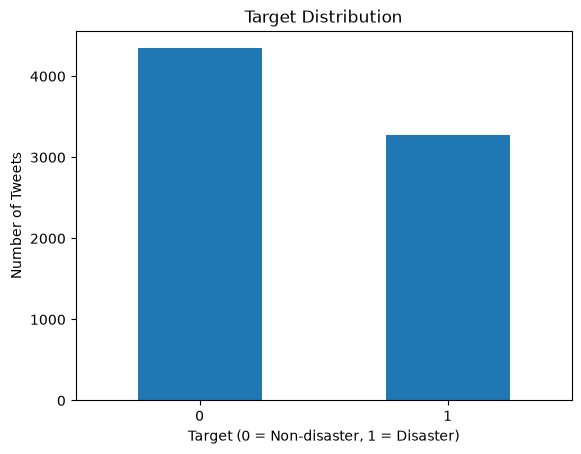

In [4]:

# Visualize target distribution
train_data["target"].value_counts().sort_index().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Target (0 = Non-disaster, 1 = Disaster)")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)
plt.show()



## 3. Inspect the Text

Before cleaning the tweets, it is useful to look at examples from both classes.

This helps identify common characteristics such as hashtags, URLs, mentions, punctuation, spelling variation, and disaster-related vocabulary.


In [5]:

pd.set_option("display.max_colwidth", 180)

print("Examples labelled 0:")
display(train_data.loc[train_data["target"] == 0, ["text"]].sample(
    min(5, (train_data["target"] == 0).sum()), random_state=RANDOM_STATE
))

print("Examples labelled 1:")
display(train_data.loc[train_data["target"] == 1, ["text"]].sample(
    min(5, (train_data["target"] == 1).sum()), random_state=RANDOM_STATE
))


Examples labelled 0:


,text
3697,Everyday is a near death fatality for me on the road. Thank god is on my side.??
4180,#Lifestyle Û÷It makes me sickÛª: Baby clothes deemed a Û÷hazardÛª http://t.co/0XrfVidxA2 http://t.co/oIHwgEZDCk
4634,@Lenn_Len Probably. We are inundated with them most years!
6135,A demoness with the voice of an angel. Like a siren's call beckoning me to the void. Don't ?? on thisÛ_ https://t.co/nPS3xpBKaQ
4568,Next Man Up---AH SCREW THIS! I'm so tired of injuries. \n\nWhat happened to Camp Cupcake? More like Camp Cramp and Break.


Examples labelled 1:


,text
4008,Nearly 50 thousand people affected by floods in #Paraguay ? http://t.co/aw23wXtyjB http://t.co/ABgct9VFUa
325,Vladimir Putin Issues Major Warning But Is It Too Late To Escape Armageddon?\nhttp://t.co/gBxafy1m1C
1215,@DoctorFluxx @StefanEJones @spinnellii @themermacorn No burning buildings and rob during a riot. That's embarrassing &amp; ruining this nation.
494,Telnet attacked from 124.13.172.40 (STREAMYX-HOME-SOUTHERN MY)
2961,LONDON IS DROWNING AND IIII LIVE BY THE RIVEEEEEER



## 4. Text Preprocessing

Tweets contain URLs, mentions, repeated whitespace, and other noise.

The preprocessing below deliberately stays conservative. We remove information that is usually not useful for this task while preserving the words themselves.

### Decisions

- Convert text to lowercase.
- Replace URLs with a token.
- Remove user mentions.
- Keep hashtag words rather than deleting them completely.
- Normalize whitespace.
- Do **not** aggressively remove stop words or punctuation at this stage.

For short social-media text, aggressive preprocessing can remove useful context.


In [6]:

def clean_tweet(text):
    """Clean a tweet while preserving useful lexical information."""
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Remove user mentions
    text = re.sub(r"@\w+", " ", text)

    # Keep the word following # but remove the hashtag symbol
    text = re.sub(r"#(\w+)", r"\1", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


train_data["clean_text"] = train_data["text"].fillna("").apply(clean_tweet)

display(train_data[["text", "clean_text"]].head(10))


,text,clean_text
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,our deeds are the reason of this earthquake may allah forgive us all
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask. canada
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,all residents asked to 'shelter in place' are being notified by officers. no other evacuation or shelter in place orders are expected
3,"13,000 people receive #wildfires evacuation orders in California","13,000 people receive wildfires evacuation orders in california"
4,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,just got sent this photo from ruby alaska as smoke from wildfires pours into a school
5,#RockyFire Update => California Hwy. 20 closed in both directions due to Lake County fire - #CAfire #wildfires,rockyfire update => california hwy. 20 closed in both directions due to lake county fire - cafire wildfires
6,"#flood #disaster Heavy rain causes flash flooding of streets in Manitou, Colorado Springs areas","flood disaster heavy rain causes flash flooding of streets in manitou, colorado springs areas"
7,I'm on top of the hill and I can see a fire in the woods...,i'm on top of the hill and i can see a fire in the woods...
8,There's an emergency evacuation happening now in the building across the street,there's an emergency evacuation happening now in the building across the street
9,I'm afraid that the tornado is coming to our area...,i'm afraid that the tornado is coming to our area...



## 5. Train / Validation Split

The validation set is kept separate from model training.

A **stratified split** is used so that the proportion of disaster and non-disaster tweets remains approximately the same in both subsets.

This also prevents a common evaluation mistake: comparing predictions from a validation subset against labels from the entire dataset.


In [7]:

X = train_data["clean_text"]
y = train_data["target"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_valid))
print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).sort_index().to_frame("proportion"))

print("\nValidation target distribution:")
display(y_valid.value_counts(normalize=True).sort_index().to_frame("proportion"))


Training samples: 6090
Validation samples: 1523

Training target distribution:


,proportion
target,
0,0.570279
1,0.429721



Validation target distribution:


,proportion
target,
0,0.570584
1,0.429416



## 6. TF-IDF + Logistic Regression

### Why TF-IDF?

TF-IDF gives greater importance to words that are informative within the dataset and less importance to words that occur frequently across many tweets.

I will use:

- `ngram_range=(1, 2)` for unigrams and bigrams
- `min_df=2` to ignore extremely rare terms
- `max_df=0.95` to ignore terms appearing in almost every document
- `sublinear_tf=True` to reduce the influence of very frequent terms

### Why Logistic Regression?

Logistic Regression is a strong baseline for binary text classification and works particularly well with sparse TF-IDF matrices.


In [8]:

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ("classifier", LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

pipeline.fit(X_train, y_train)

valid_predictions = pipeline.predict(X_valid)


In [9]:

# Evaluation
accuracy = accuracy_score(y_valid, valid_predictions)
precision = precision_score(y_valid, valid_predictions)
recall = recall_score(y_valid, valid_predictions)
f1 = f1_score(y_valid, valid_predictions)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification report:")
print(classification_report(
    y_valid,
    valid_predictions,
    target_names=["Non-disaster", "Disaster"]
))


Accuracy : 0.8188
Precision: 0.8412
Recall   : 0.7125
F1-score : 0.7715

Classification report:
              precision    recall  f1-score   support

Non-disaster       0.81      0.90      0.85       869
    Disaster       0.84      0.71      0.77       654

    accuracy                           0.82      1523
   macro avg       0.82      0.81      0.81      1523
weighted avg       0.82      0.82      0.82      1523



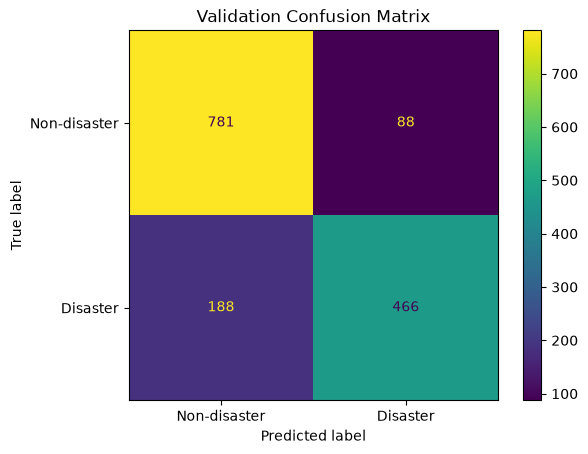

In [10]:

# Confusion matrix
cm = confusion_matrix(y_valid, valid_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-disaster", "Disaster"]
)
disp.plot()
plt.title("Validation Confusion Matrix")
plt.show()



## 7. Interpreting the Evaluation

The four main metrics answer different questions:

- **Accuracy:** How many tweets were classified correctly overall?
- **Precision:** When the model predicts a disaster, how often is it correct?
- **Recall:** Of all real disaster tweets, how many did the model identify?
- **F1-score:** A balance between precision and recall.

For this project, F1-score is especially useful because it considers both types of classification error rather than relying only on overall accuracy.



## 8. Hyperparameter Tuning

The main Logistic Regression parameter to tune is `C`.

`C` controls the strength of regularization:

- Smaller `C` → stronger regularization.
- Larger `C` → weaker regularization.

Instead of choosing a value based on the validation set repeatedly, cross-validation is used on the training data.


In [11]:

param_grid = {
    "classifier__C": [0.25, 0.5, 1.0, 2.0, 4.0]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-validation F1: {grid_search.best_score_:.4f}")


Best parameters: {'classifier__C': 2.0}
Best cross-validation F1: 0.7443


In [12]:

# Evaluate the tuned model on the untouched validation set
tuned_model = grid_search.best_estimator_
tuned_predictions = tuned_model.predict(X_valid)

print(classification_report(
    y_valid,
    tuned_predictions,
    target_names=["Non-disaster", "Disaster"]
))

print(f"Validation accuracy: {accuracy_score(y_valid, tuned_predictions):.4f}")
print(f"Validation F1:       {f1_score(y_valid, tuned_predictions):.4f}")


              precision    recall  f1-score   support

Non-disaster       0.81      0.88      0.85       869
    Disaster       0.82      0.73      0.77       654

    accuracy                           0.82      1523
   macro avg       0.82      0.81      0.81      1523
weighted avg       0.82      0.82      0.81      1523

Validation accuracy: 0.8162
Validation F1:       0.7735



## 9. Inspect the Most Important Features

One advantage of Logistic Regression is that its coefficients can be inspected.

Positive coefficients indicate terms that push predictions toward the disaster class, while negative coefficients push predictions toward the non-disaster class.

This provides an interpretable view of what the model has learned.


In [13]:

vectorizer = tuned_model.named_steps["tfidf"]
classifier = tuned_model.named_steps["classifier"]

feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = classifier.coef_[0]

top_disaster = feature_names[np.argsort(coefficients)[-25:][::-1]]
top_non_disaster = feature_names[np.argsort(coefficients)[:25]]

print("Top features associated with DISASTER:")
print(", ".join(top_disaster))

print("\nTop features associated with NON-DISASTER:")
print(", ".join(top_non_disaster))


Top features associated with DISASTER:
hiroshima, in, fires, storm, california, wildfire, fire, train, floods, killed, near, massacre, police, suicide, earthquake, japan, bombing, buildings, tornado, typhoon, mass, accident, forest, attack, drought

Top features associated with NON-DISASTER:
you, my, new, love, full, he, let, traumatised, upheaval, bloody, body, or, nowplaying, flattened, stretcher, blizzard, blazing, wrecked, bags, his, harm, show, all, finally, deluge



## 10. Error Analysis

A useful NLP analysis does not stop at a single metric. We should inspect tweets the model classified incorrectly.

There are two important error types:

- **False positives:** predicted as disaster, but actually non-disaster.
- **False negatives:** predicted as non-disaster, but actually disaster.

These examples can reveal ambiguity, figurative language, missing context, and vocabulary that the model struggles to interpret.


In [14]:

error_analysis = pd.DataFrame({
    "text": train_data.loc[X_valid.index, "text"],
    "clean_text": X_valid,
    "actual": y_valid,
    "predicted": tuned_predictions
})

false_positives = error_analysis[
    (error_analysis["actual"] == 0) &
    (error_analysis["predicted"] == 1)
]

false_negatives = error_analysis[
    (error_analysis["actual"] == 1) &
    (error_analysis["predicted"] == 0)
]

print(f"False positives: {len(false_positives)}")
display(false_positives[["text", "actual", "predicted"]].head(15))

print(f"False negatives: {len(false_negatives)}")
display(false_negatives[["text", "actual", "predicted"]].head(15))


False positives: 104


,text,actual,predicted
4863,@TheEconomist Step one: get that mass murderer's portrait off the yuan.,0,1
1318,@nagel_ashley @Vicken52 @BasedLaRock @goonc1ty rip the world... its burning,0,1
1358,if firefighters acted like cops they'd drive around shooting a flamethrower at burning buildings,0,1
244,@POTUS Maybe we should call Israel and tell them we're sorry are Pres has sold them down the river to annihilation.,0,1
5267,@TroySlaby22 slicker than an oil spill,0,1
5119,Has An Ancient Nuclear Reactor Been Discovered In Africa? ÛÒ Your... http://t.co/qadUfO8zXg,0,1
809,Article by Michael Jackman at Metro Times Detroit:\nThe group later downgraded the estimate to 37 square miles of... http://t.co/h31mmuduqt,0,1
1660,Look: #I have collapsed #after attempting to munch an endangered species.,0,1
5017,The 19 year old's smug face when Dorret brings out her mudslide Black Forest gateau #priceless #GBBO,0,1
4955,DFR EP016 Monthly Meltdown - On Dnbheaven 2015.08.06 http://t.co/EjKRf8N8A8 #Drum and Bass #heavy #nasty http://t.co/SPHWE6wFI5,0,1


False negatives: 176


,text,actual,predicted
6837,Hollywood Movie About Trapped Miners Released in Chile: 'The 33' Hollywood movie about trapped miners starring... http://t.co/tyyfG4qQvM,1,0
2905,I can't drown my demons they know how to swim,1,0
1956,@XHNews We need these plants in the pacific during the cyclone seasons it would help,1,0
5020,'It looks like a mudslide' poor thing! ?? #greatbritishbakeoff,1,0
7605,on the flip side I'm at Walmart and there is a bomb and everyone had to evacuate so stay tuned if I blow up or not,1,0
6006,I agree with certain cultural appropriation things but honestly if u looked at my house it screams appropriation bc Buddhas and stuff-,1,0
3441,The Dress Memes Have Officially Exploded On The Internet http://t.co/3drSmxw3cr,1,0
6488,Aquarium Ornament Wreck Sailing Boat Sunk Ship Destroyer Fish Tank Cave Decor - Full read Û_ http://t.co/nosA8JJjiN http://t.co/WUKvdavUJu,1,0
4436,The horrific story of being a hostage - The horrific story of being a hostage It's 1974 and on a British... http://t.co/XcQ48OuRvL,1,0
5642,Newlyweds feed thousands of Syrian refugees instead of hosting a banquet wedding dinner - http://t.co/XZV0lT9ZZk via @smh,1,0



## 11. Final Model

After model selection, the chosen pipeline can be retrained on all labelled data before being used on unseen tweets.

The advantage of using a single scikit-learn `Pipeline` is that preprocessing, TF-IDF fitting, and classification remain connected and are less likely to be applied inconsistently.


In [15]:

final_model = tuned_model
final_model.fit(X, y)

print("Final model trained on all available labelled tweets.")


Final model trained on all available labelled tweets.



## 12. Try the Model on New Tweets

Edit the examples below and run the cell to see the predicted class and probability.

The probability is the model's estimated probability for the disaster class; it should not be interpreted as certainty.


In [16]:

new_tweets = [
    "A massive earthquake has destroyed several buildings.",
    "I had a disaster trying to cook dinner tonight!",
    "Firefighters are responding to a large wildfire.",
    "This movie was an absolute disaster."
]

new_clean = [clean_tweet(tweet) for tweet in new_tweets]

predictions = final_model.predict(new_clean)
probabilities = final_model.predict_proba(new_clean)[:, 1]

results = pd.DataFrame({
    "tweet": new_tweets,
    "prediction": predictions,
    "disaster_probability": probabilities.round(3)
})

results["prediction_label"] = results["prediction"].map({
    0: "Non-disaster",
    1: "Disaster"
})

display(results)


,tweet,prediction,disaster_probability,prediction_label
0,A massive earthquake has destroyed several buildings.,1,0.810,Disaster
1,I had a disaster trying to cook dinner tonight!,0,0.382,Non-disaster
2,Firefighters are responding to a large wildfire.,1,0.824,Disaster
3,This movie was an absolute disaster.,0,0.489,Non-disaster



# 13. Conclusions

### What the model does well

The TF-IDF + Logistic Regression approach provides a strong and relatively interpretable baseline for short text classification. It can learn associations between disaster-related vocabulary and the target label without requiring a large neural network.

### Main limitations

1. **Limited context:** Tweets are short and may require external knowledge to interpret correctly.
2. **Ambiguous language:** Words such as "disaster" or "fire" can be used metaphorically.
3. **Vocabulary dependence:** TF-IDF mainly learns from patterns seen in the training data.
4. **No deep semantic understanding:** Similar meanings expressed with very different words may not be recognized as equivalent.
5. **Dataset bias:** The model can reproduce patterns and biases present in the labelled training data.

### Possible future improvements

- Word + character n-gram TF-IDF
- Linear SVM
- Class-weight tuning
- More extensive cross-validation
- Transformer-based models such as BERT/RoBERTa
- Error-driven feature engineering

### Presentation takeaway

The important result is not simply the final score. The project demonstrates a complete reasoning process:

**messy text → preprocessing → numerical representation → classification → evaluation → error analysis → improvement**

That is the key NLP workflow demonstrated by this project.
